<a href="https://colab.research.google.com/github/LeonimerMelo/Recurrent-Networks/blob/LSTM/Time_Series_Price_Anomaly_(Outlier)_Detection_with_LSTM_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Anomalies/Outliers Time-Series
From a traditional point of view, an outlier/anomaly is: “An observation which deviates so much from other observations as to arouse suspicions that it was generated by a different mechanism.” Therefore, you can think of outliers as observations that don’t follow the expected behavior.

**Point outlier** is a datum that behaves unusually in a specific time instance when compared either to the other values in the time series (global outlier), or to its neighboring points (local outlier). Point outliers can be univariate or multivariate, depending on whether they affect one or more time-dependent variables, respectively. Fig. contains two univariate point outliers, O1 and O2, whereas the multivariate time series is composed of three variables in Fig. 3b, and has both univariate (O3) and multivariate (O1 and O2) point outliers.

<center><img src='https://i0.wp.com/neptune.ai/wp-content/uploads/2022/10/Point-outliers-in-time-series.png?resize=750%2C301&ssl=1' width=900></center>

**Subsequence outlier**. This means consecutive points in time whose joint behavior is unusual, although each observation individually is not necessarily a point outlier. Subsequence outliers can also be global or local, and can affect one (univariate subsequence outlier) or more (multivariate subsequence outlier) time-dependent variables.

Fig. provides an example of univariate (O1 and O2 in Fig. 2a, and O3 in Fig. 2b) and multivariate (O1 and O2 in Fig. 2b) subsequence outliers. Note that the latter does not necessarily affect all the variables (e.g., O2 in Fig. 2b).

<center><img src='https://i0.wp.com/neptune.ai/wp-content/uploads/2022/10/%E2%80%8ASubsequence-outliers-in-time-series.png?ssl=1' width=900></center>

##What is an Anomaly Detection Algorithm?
Anomaly detection is the process of identifying data points that deviate from the expected patterns in a dataset. Many applications, including fraud detection, intrusion detection, and failure detection, often use anomaly detection techniques. Finding uncommon or very infrequent events that could point to a possible hazard, issue, or opportunity is the aim of anomaly detection.

###Autoencoder
The autoencoder algorithm is an unsupervised deep learning algorithm that can be used for anomaly detection in time series data. The autoencoder is a neural network that learns to reconstruct its input data By first compressing input data into a lower-dimensional representation and then extending it back to its original dimensions. An autoencoder may be trained on typical time series data to learn a compressed version of the data for anomaly identification. The anomaly score may then be calculated using the reconstruction error between the original and reconstructed data. Anomalies are data points with considerable reconstruction errors.

###What is an AutoEncoder?
An AutoEncoder is a type of neural network used for unsupervised learning. Its primary function is to learn a compressed representation of input data. An AutoEncoder consists of two main parts: the encoder and the decoder.

**Encoder**: This part of the network compresses the input into a latent-space representation. It encodes the input data as an encoded (compressed) representation in a reduced dimension.

**Decoder**: The decoder part aims to reconstruct the input data from the encoded representation. It tries to generate an output that is as close as possible to the original input.

The key idea is that AutoEncoders are trained to minimize reconstruction errors, which makes them efficient in learning the distribution of the input data.

##Time Series Data and Anamoly Detection
In the case of time series data, anomaly detection algorithms are especially important since they help us spot odd patterns in the data that would not be obvious from just looking at the raw data. Anomalies in time series data might appear as abrupt increases or decrease in values, odd patterns, or unexpected seasonality. Time series data is a collection of observations across time.

Time series data may be used to teach anomaly detection algorithms, such as the autoencoder, how to represent typical patterns. These algorithms can then utilize this representation to find anomalies. The approach can learn a compressed version of the data by training an autoencoder on regular time series data. The anomaly score may then be calculated using the reconstruction error between the original and reconstructed data. Anomalies are data points with considerable reconstruction errors.

Anomaly detection algorithms may be applied to time series data to find odd patterns that could point to a hazard, issue, or opportunity. For instance, in the context of predictive maintenance, a time series anomaly may point to a prospective equipment failure that may be fixed before it results in a large amount of downtime or safety concerns. Anomalies in time series data may reveal market movements or patterns in financial forecasts that may be capitalized on.

##AutoEncoders for Anomaly Detection
In the context of anomaly detection, AutoEncoders are particularly useful. They are trained on normal data to learn the representation of the normal state. During inference, if an input significantly deviates from this learned representation, the AutoEncoder will likely reconstruct it poorly. This poor reconstruction is a signal of an anomaly.

###How It Works
**Training**: The AutoEncoder is trained exclusively on normal data. The training process involves adjusting the weights to minimize the reconstruction error.

**Inference**: During inference, we feed new data to the Autoencoder. If the data is normal, the AutoEncoder will successfully reconstruct it with minimal error. However, if the data is anomalous, the reconstruction error will be significantly higher.

**Thresholding**: We set a threshold for the reconstruction error. If the error surpasses this threshold, the data point is flagged as an anomaly.

<center><img src='https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs43588-021-00128-6/MediaObjects/43588_2021_128_Fig1_HTML.png' width=900></center>

##Time Series Price Anomaly (Outlier) Detection with LSTM
Autoencoders are an unsupervised learning technique, although they are trained using supervised learning methods. The goal is to minimize reconstruction error based on a loss function, such as the mean squared error. In this exemple, we will try to detect anomalies in the Johnson & Johnson’s historical stock price time series data with an LSTM autoencoder. The data can be downloaded from Yahoo Finance. The time period that was selected was from 1985–01–02 to 2024–06–25. The steps we will follow to detect anomalies in Johnson & Johnson stock price data using an LSTM autoencoder:

- Train an LSTM autoencoder on the Johnson & Johnson’s stock price data from 1985–01–02 to 2017-03-01. We assume that there were no anomalies and they were normal.
- Using the LSTM autoencoder to reconstruct the error on the test data from 2017-03-01 to 2024–06–25.
- If the reconstruction error for the test data is above the threshold, we label the data point as an anomaly.

We will break down an LSTM autoencoder network to understand them layer-by-layer.

In [ ]:
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import tensorflow as tf
import plotly.graph_objects as go

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
np.random.seed(1)
tf.random.set_seed(1)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input, RepeatVector, TimeDistributed

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/JNJ_3.csv')
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,1985-01-02,2.242188,2.250000,2.218750,2.226563,0.883506,3361600
1,1985-01-03,2.226563,2.257813,2.195313,2.195313,0.871106,5819200
2,1985-01-04,2.203125,2.234375,2.195313,2.234375,0.886606,3787200
3,1985-01-07,2.242188,2.250000,2.234375,2.234375,0.886606,2508800
4,1985-01-08,2.242188,2.296875,2.242188,2.257813,0.895906,5800000
...,...,...,...,...,...,...,...
9942,2024-06-14,145.139999,145.970001,144.479996,145.539993,145.539993,4075300
9943,2024-06-17,145.020004,146.429993,144.740005,145.949997,145.949997,6666600
9944,2024-06-18,145.960007,146.389999,145.259995,145.649994,145.649994,6156600
9945,2024-06-20,145.270004,148.080002,145.009995,147.779999,147.779999,8749700


In [ ]:
df = df[['Date', 'Close']].copy()
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].min(), df['Date'].max()

(Timestamp('1985-01-02 00:00:00'), Timestamp('2024-06-21 00:00:00'))

In [ ]:
df

,Date,Close
0,1985-01-02,2.226563
1,1985-01-03,2.195313
2,1985-01-04,2.234375
3,1985-01-07,2.234375
4,1985-01-08,2.257813
...,...,...
9942,2024-06-14,145.539993
9943,2024-06-17,145.949997
9944,2024-06-18,145.649994
9945,2024-06-20,147.779999


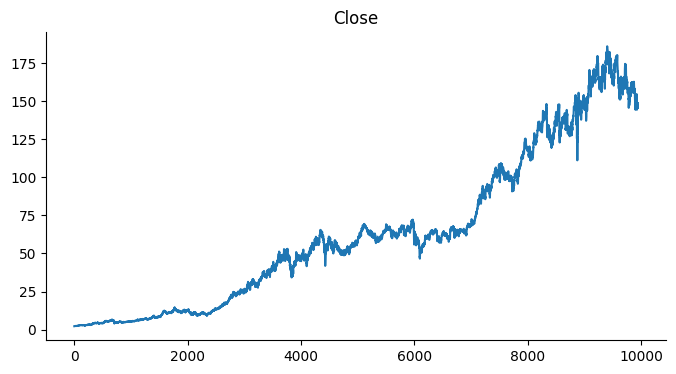

In [ ]:
from matplotlib import pyplot as plt
df['Close'].plot(kind='line', figsize=(8, 4), title='Close')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
# Visualize the time series
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['Date'], y=df['Close'], name='Close price'))
fig.update_layout(showlegend=True, title='Johnson and Johnson Stock Price 1985-2024')
fig.show()

In [ ]:
train, test = df.loc[df['Date'] <= '2017-03-01'], df.loc[df['Date'] > '2017-03-01']
train.shape, test.shape

((8108, 2), (1839, 2))

In [ ]:
train

,Date,Close
0,1985-01-02,2.226563
1,1985-01-03,2.195313
2,1985-01-04,2.234375
3,1985-01-07,2.234375
4,1985-01-08,2.257813
...,...,...
8103,2017-02-23,121.699997
8104,2017-02-24,122.730003
8105,2017-02-27,122.400002
8106,2017-02-28,122.209999


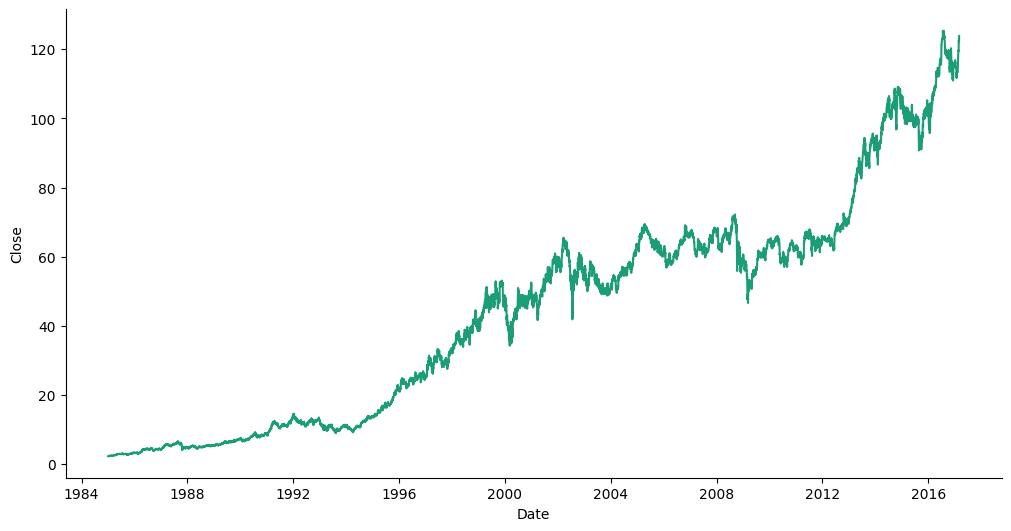

In [ ]:
# @title Date vs Close

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Date']
  ys = series['Close']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = train.sort_values('Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
_ = plt.ylabel('Close')

In [ ]:
scaler = StandardScaler()
scaler = scaler.fit(train[['Close']])

train_sc = scaler.transform(train[['Close']].copy())
test_sc = scaler.transform(test[['Close']].copy())

In [ ]:
train_sc

array([[-1.32288143],
       [-1.3238686 ],
       [-1.32263465],
       ...,
       [ 2.47333708],
       [ 2.46733498],
       [ 2.51945771]])

In [ ]:
train_sc.shape

(8108, 1)

In [ ]:
train_sc.reshape(-1).shape

(8108,)

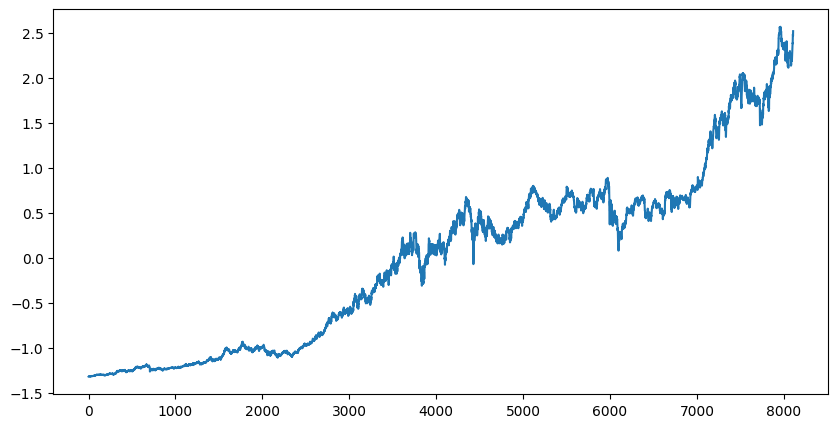

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_sc)
plt.show()

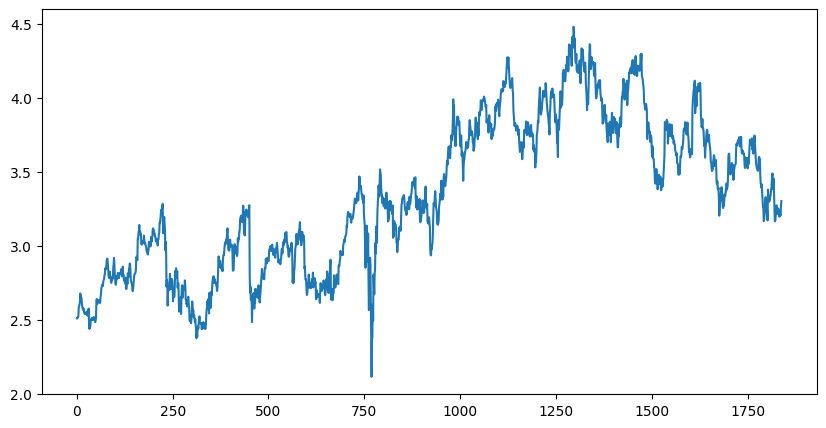

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(test_sc)
plt.show()

In [ ]:
train[['Close']]

,Close
0,2.226563
1,2.195313
2,2.234375
3,2.234375
4,2.257813
...,...
8103,121.699997
8104,122.730003
8105,122.400002
8106,122.209999


In [ ]:
train[['Close']].shape, train['Close'].shape

((8108, 1), (8108,))

###Create sequences
Convert input data into 3-D array combining TIME_STEPS. The shape of the array should be [samples, TIME_STEPS, features], as required for LSTM network.

We want our network to have memory of 30 days, so we set TIME_STEPS=30.

In [ ]:
TIME_STEPS=30

def create_sequences(X, y, time_steps=TIME_STEPS):
    Xs, ys = [], []
    for i in range(len(X)-time_steps):
        Xs.append(X[i:(i+time_steps)])
        ys.append(y[i+time_steps])

    return np.array(Xs), np.array(ys)

X_train, y_train = create_sequences(train_sc, train_sc.reshape(-1))
X_test, y_test = create_sequences(test_sc, test_sc.reshape(-1))

print(f'Training shape: {X_train.shape}')
print(f'Testing shape: {X_test.shape}')

Training shape: (8078, 30, 1)
Testing shape: (1809, 30, 1)


In [ ]:
X_train[0]

array([[-1.32288143],
       [-1.3238686 ],
       [-1.32263465],
       [-1.32263465],
       [-1.32189425],
       [-1.32115389],
       [-1.31893274],
       [-1.31991991],
       [-1.31868596],
       [-1.31917955],
       [-1.31942632],
       [-1.31967313],
       [-1.31967313],
       [-1.31843915],
       [-1.31917955],
       [-1.31819238],
       [-1.31942632],
       [-1.3204135 ],
       [-1.31942632],
       [-1.31819238],
       [-1.31671162],
       [-1.31621803],
       [-1.31769879],
       [-1.31819238],
       [-1.31769879],
       [-1.31917955],
       [-1.31769879],
       [-1.31745198],
       [-1.31769879],
       [-1.31671162]])

In [ ]:
X_train.min(), X_train.max()

(-1.3238685970122335, 2.568105566985181)

###Build the Model
We define the reconstruction LSTM Autoencoder architecture that expects input sequences with 30 time steps and one feature and outputs a sequence with 30 time steps and one feature.

RepeatVector() repeats the inputs 30 times.

Set return_sequences=True, so the output will still be a sequence.

TimeDistributed(Dense(X_train.shape[2])) is added at the end to get the output, where X_train.shape[2] is the number of features in the input data.

In [ ]:
model = Sequential()
model.add(LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(rate=0.2))
model.add(RepeatVector(X_train.shape[1]))
model.add(LSTM(128, return_sequences=True))
model.add(Dropout(rate=0.2))
model.add(TimeDistributed(Dense(X_train.shape[2])))
model.compile(optimizer='adam', loss='mae')
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_10 (LSTM)              (None, 128)               66560     
                                                                 
 dropout_9 (Dropout)         (None, 128)               0         
                                                                 
 repeat_vector_5 (RepeatVec  (None, 30, 128)           0         
 tor)                                                            
                                                                 
 lstm_11 (LSTM)              (None, 30, 128)           131584    
                                                                 
 dropout_10 (Dropout)        (None, 30, 128)           0         
                                                                 
 time_distributed_4 (TimeDi  (None, 30, 1)             129       
 stributed)                                           

In [ ]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1,
                    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, mode='min')], shuffle=False)

Epoch 1/100
228/228 [==============================] - 11s 14ms/step - loss: 0.1421 - val_loss: 0.3062
Epoch 2/100
228/228 [==============================] - 2s 9ms/step - loss: 0.1027 - val_loss: 0.1954
Epoch 3/100
228/228 [==============================] - 2s 9ms/step - loss: 0.1081 - val_loss: 0.2028
Epoch 4/100
228/228 [==============================] - 2s 10ms/step - loss: 0.0965 - val_loss: 0.2780
Epoch 5/100
228/228 [==============================] - 3s 12ms/step - loss: 0.1123 - val_loss: 0.2690


In [ ]:
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1, shuffle=False)

Epoch 1/5
228/228 [==============================] - 7s 15ms/step - loss: 0.1237 - val_loss: 0.1694
Epoch 2/5
228/228 [==============================] - 2s 8ms/step - loss: 0.0963 - val_loss: 0.0967
Epoch 3/5
228/228 [==============================] - 2s 8ms/step - loss: 0.0805 - val_loss: 0.1083
Epoch 4/5
228/228 [==============================] - 2s 7ms/step - loss: 0.0765 - val_loss: 0.1331
Epoch 5/5
228/228 [==============================] - 2s 8ms/step - loss: 0.0858 - val_loss: 0.0959


In [ ]:
model.save('my_model.keras')

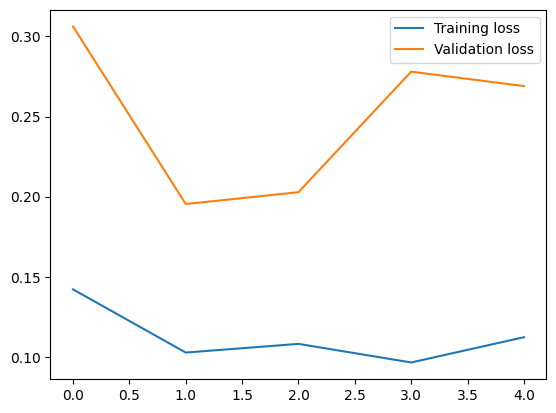

In [ ]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend();

In [ ]:
# Returns the loss value & metrics values for the model in test mode
model.evaluate(X_test, y_test)

57/57 [==============================] - 0s 5ms/step - loss: 1.1558


1.1558213233947754

###Determine Anomalies
Find MAE loss on the training data.

Make the max MAE loss value in the training data as the reconstruction error threshold.

If the reconstruction loss for a data point in the test set is greater than this reconstruction error threshold value then we will label this data point as an anomaly.

Reconstruction error threshold: 0.9674183181201008


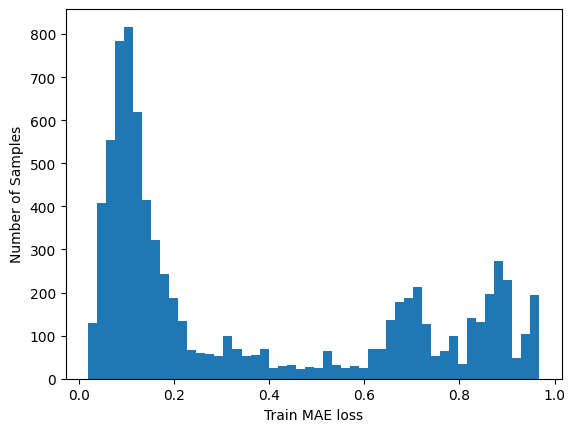

In [ ]:
X_train_pred = model.predict(X_train, verbose=0)
train_mae_loss = np.mean(np.abs(X_train_pred - X_train), axis=1)

plt.hist(train_mae_loss, bins=50)
plt.xlabel('Train MAE loss')
plt.ylabel('Number of Samples');

threshold = np.max(train_mae_loss)
print(f'Reconstruction error threshold: {threshold}')

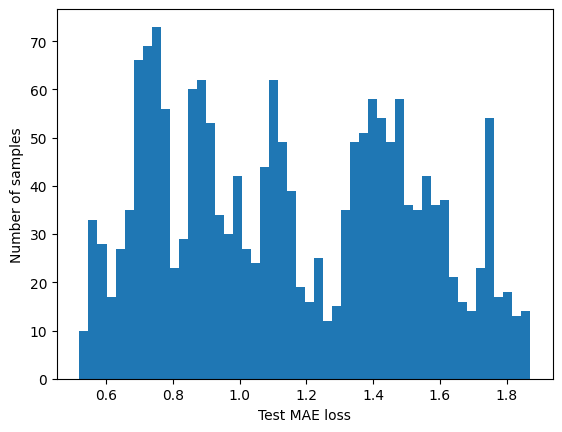

In [ ]:
X_test_pred = model.predict(X_test, verbose=0)
test_mae_loss = np.mean(np.abs(X_test_pred-X_test), axis=1)

plt.hist(test_mae_loss, bins=50)
plt.xlabel('Test MAE loss')
plt.ylabel('Number of samples');

In [ ]:
test_score_df = pd.DataFrame(test[TIME_STEPS:])
test_score_df['loss'] = test_mae_loss
test_score_df['threshold'] = threshold
test_score_df['anomaly'] = test_score_df['loss'] > test_score_df['threshold']
test_score_df['Close'] = test[TIME_STEPS:]['Close']

fig = go.Figure()
fig.add_trace(go.Scatter(x=test_score_df['Date'], y=test_score_df['loss'], name='Test loss'))
fig.add_trace(go.Scatter(x=test_score_df['Date'], y=test_score_df['threshold'], name='Threshold'))
fig.update_layout(showlegend=True, title='Test loss vs. Threshold')
fig.show()

In [ ]:
anomalies = test_score_df.loc[test_score_df['anomaly'] == True]
anomalies.shape

(1118, 5)

As you can see, there are 2 data points in the test set that exceeded the reconstruction error threshold.

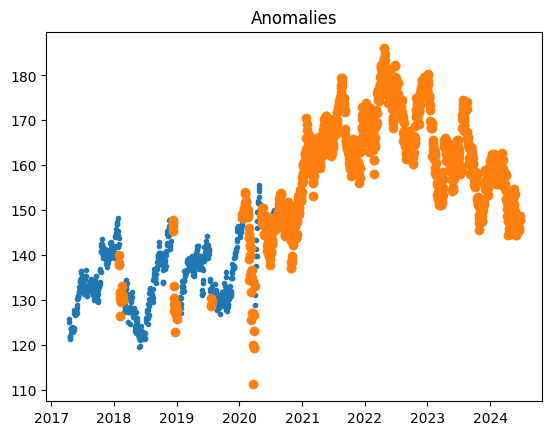

In [ ]:
plt.plot(test_score_df['Date'], test_score_df['Close'], '.')
plt.plot(anomalies['Date'], anomalies['Close'], 'o')
plt.title('Anomalies')
plt.show()

In [ ]:
test_score_df['Date'].shape

(1809,)

In [ ]:
test_score_df['Close'].shape

(1809,)

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=test_score_df['Date'], y=test_score_df['Close'], name='Close price'))
fig.add_trace(go.Scatter(x=anomalies['Date'], y=anomalies['Close'], mode='markers', name='Anomaly'))
fig.update_layout(showlegend=True, title='Detected anomalies')
fig.show()

The model found that some low price anomalies in March. As it was well documented that JNJ stock hit a 2020 low in March, but quickly reaccelerated to a high point less than a month later on bullish expectations for its **coronavirus vaccine**.

##Exercícios
1. Proceda o treinamento da rede com 10, 30, 50 e 100 épocas e verifique e comente os resultados.
1. Modifique o batch size para `batch_size=8, 16, 64 e 128` utilizando a quantidade de épocas com os melhores resultados. Comente os resultados.
1. Modifique o `TIME_STEPS` para 50, 100, 200 e 500. Comente os resultados.
1. Descreva com detalhes as funções utilizadas na arquitetura da rede.
1. Modifique a quantidade de unidades LSTM para: 32, 50, 64, 256. Treine a rede para cada caso e compare os resultados.
1. Acrescente mais uma camada oculta LSTM com a quantidade de unidades que melhor desempenho obteve nos testes anteriores. Treine a rede e compare os resultados.
1. Modifique a taxa do *Dropout* para 0%, 10% e 30%. Treine a rede e compare os resultados.
1. Modifique o *learning rate* do otimizador Adam para 0.0001. Treine a rede e compare os resultados.
1. Pesquise um banco de dados de séries temporais que apresente alguma anomalia. Treine a rede nesse novo banco de dados. Comente os resultados.




##Referência
[1] https://towardsdatascience.com/time-series-of-price-anomaly-detection-with-lstm-11a12ba4f6d9

[2] https://neptune.ai/blog/anomaly-detection-in-time-series

[3] https://medium.com/aimonks/anomaly-detection-for-time-series-analysis-eeecd6282f53

[4] https://www.geeksforgeeks.org/anomaly-detection-in-time-series-data/

[5] https://medium.com/@weidagang/demystifying-anomaly-detection-with-autoencoder-neural-networks-1e235840d879